# Rotation Transformations

## Purpose

Understand 2D rotation matrices by looking at where the basis vectors land.

In the previous notebook, we saw scaling, reflection, and shear as different ways to move the basis vectors.

Rotation is another transformation of the same kind.

The key idea is still:

> the matrix moves the basis vectors, then every other vector is rebuilt from those moved basis vectors.

For rotation, the basis vectors turn together while keeping their length and staying at right angles.

## Setup

We will use the standard basis vectors:

$$
\mathbf{e}_1 =
\begin{bmatrix}
1 \\
0
\end{bmatrix}
\qquad
\mathbf{e}_2 =
\begin{bmatrix}
0 \\
1
\end{bmatrix}
$$

and a familiar example vector:

$$
\mathbf{v} =
\begin{bmatrix}
2 \\
1
\end{bmatrix}
=
2\mathbf{e}_1 + 1\mathbf{e}_2
$$

Keeping the same vector makes it easier to compare this notebook with the previous ones.

In [1]:
import numpy as np
import matplotlib.pyplot as plt


e1 = np.array([1.0, 0.0])
e2 = np.array([0.0, 1.0])
v = np.array([2.0, 1.0])


def setup_axis(ax, title, xlim=(-2.75, 2.75), ylim=(-1.75, 2.75)):
    ax.axhline(0, linewidth=1)
    ax.axvline(0, linewidth=1)
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_aspect("equal", adjustable="box")
    ax.grid(True, alpha=0.3)
    ax.set_title(title)
    ax.set_xlabel("x")
    ax.set_ylabel("y")


def draw_vector(
    ax,
    vector,
    origin=(0, 0),
    label=None,
    label_offset=(0.08, 0.08),
    linewidth=2,
    alpha=1.0,
    linestyle="-",
):
    origin = np.array(origin, dtype=float)
    vector = np.array(vector, dtype=float)

    ax.arrow(
        origin[0],
        origin[1],
        vector[0],
        vector[1],
        length_includes_head=True,
        head_width=0.08,
        head_length=0.12,
        linewidth=linewidth,
        alpha=alpha,
        linestyle=linestyle,
    )

    if label is not None:
        end = origin + vector
        ax.text(
            end[0] + label_offset[0],
            end[1] + label_offset[1],
            label,
            fontsize=11,
        )


def rotation_matrix(degrees):
    radians = np.deg2rad(degrees)
    cos_theta = np.cos(radians)
    sin_theta = np.sin(radians)

    return np.array([
        [cos_theta, -sin_theta],
        [sin_theta, cos_theta],
    ])


def print_vector(name, vector):
    print(f"{name} = [{vector[0]: .3f}, {vector[1]: .3f}]")


def show_rotation(R, title, xlim=(-2.75, 2.75), ylim=(-1.75, 2.75)):
    Re1 = R @ e1
    Re2 = R @ e2
    Rv = R @ v

    print("R =")
    print(np.round(R, 3))
    print()
    print_vector("Re1", Re1)
    print_vector("Re2", Re2)
    print_vector("Rv ", Rv)

    fig, ax = plt.subplots(figsize=(5.2, 4.2))
    setup_axis(ax, title, xlim=xlim, ylim=ylim)

    # Faint original references.
    draw_vector(ax, e1, label="$e_1$", label_offset=(0.04, -0.22), alpha=0.35, linewidth=1.5)
    draw_vector(ax, e2, label="$e_2$", label_offset=(-0.25, 0.06), alpha=0.35, linewidth=1.5)
    draw_vector(ax, v, label="$v$", label_offset=(0.08, 0.08), alpha=0.35, linewidth=1.5)

    # Rotated basis vectors and rotated example vector.
    draw_vector(ax, Re1, label="$Re_1$", label_offset=(0.08, 0.06), linewidth=2.2)
    draw_vector(ax, Re2, label="$Re_2$", label_offset=(0.08, 0.06), linewidth=2.2)
    draw_vector(ax, Rv, label="$Rv$", label_offset=(0.08, 0.08), linewidth=2.5)

    plt.show()


def plot_angle_sweep(degrees_list, xlim=(-2.75, 2.75), ylim=(-2.75, 2.75)):
    fig, ax = plt.subplots(figsize=(5.8, 5.2))
    setup_axis(ax, "Same vector rotated through several angles", xlim=xlim, ylim=ylim)

    radius = np.linalg.norm(v)
    circle = plt.Circle((0, 0), radius, fill=False, linestyle="--", alpha=0.35)
    ax.add_patch(circle)

    draw_vector(ax, v, label="$v$", label_offset=(0.08, 0.08), alpha=0.35, linewidth=1.5)

    for degrees in degrees_list:
        R = rotation_matrix(degrees)
        Rv = R @ v
        draw_vector(
            ax,
            Rv,
            label=f"{degrees}°",
            label_offset=(0.08, 0.08),
            linewidth=1.8,
        )

    plt.show()

## A 90-degree rotation

A 90-degree counter-clockwise rotation uses the matrix:

$$
R =
\begin{bmatrix}
0 & -1 \\
1 & 0
\end{bmatrix}
$$

Read by columns, this says:

$$
R\mathbf{e}_1 =
\begin{bmatrix}
0 \\
1
\end{bmatrix}
\qquad
R\mathbf{e}_2 =
\begin{bmatrix}
-1 \\
0
\end{bmatrix}
$$

So the x-basis vector rotates up, and the y-basis vector rotates left.

R =
[[ 0. -1.]
 [ 1.  0.]]

Re1 = [ 0.000,  1.000]
Re2 = [-1.000,  0.000]
Rv  = [-1.000,  2.000]


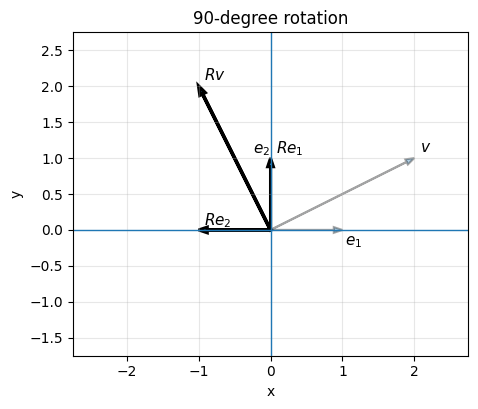

In [2]:
R90 = np.array([
    [0.0, -1.0],
    [1.0, 0.0],
])

show_rotation(R90, title="90-degree rotation")

The example vector was:

$$
\mathbf{v} = 2\mathbf{e}_1 + 1\mathbf{e}_2
$$

After rotation:

$$
R\mathbf{v} = 2(R\mathbf{e}_1) + 1(R\mathbf{e}_2)
$$

The coefficients are still $2$ and $1$.

The basis vectors have turned, so the vector turns with them.

## The general 2D rotation matrix

For an angle $\theta$, the standard counter-clockwise rotation matrix is:

$$
R_\theta =
\begin{bmatrix}
\cos(\theta) & -\sin(\theta) \\
\sin(\theta) & \cos(\theta)
\end{bmatrix}
$$

This looks less mysterious when read by columns.

The first column is where $\mathbf{e}_1$ lands:

$$
R_\theta\mathbf{e}_1 =
\begin{bmatrix}
\cos(\theta) \\
\sin(\theta)
\end{bmatrix}
$$

The second column is where $\mathbf{e}_2$ lands:

$$
R_\theta\mathbf{e}_2 =
\begin{bmatrix}
-\sin(\theta) \\
\cos(\theta)
\end{bmatrix}
$$

So the columns are the rotated basis vectors.

## A 45-degree rotation

Now rotate the same vector by 45 degrees.

This is still the same idea:

$$
R\mathbf{v} = 2(R\mathbf{e}_1) + 1(R\mathbf{e}_2)
$$

Only the angle has changed.

R =
[[ 0.707 -0.707]
 [ 0.707  0.707]]

Re1 = [ 0.707,  0.707]
Re2 = [-0.707,  0.707]
Rv  = [ 0.707,  2.121]


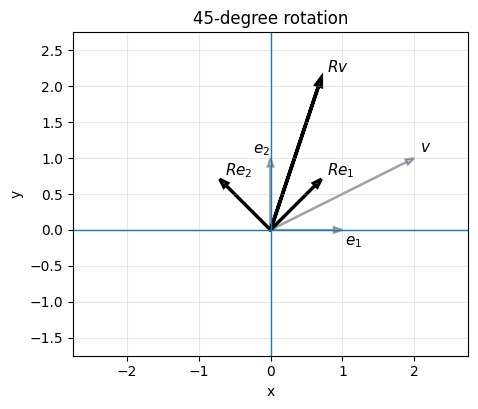

In [3]:
R45 = rotation_matrix(45)

show_rotation(R45, title="45-degree rotation")

The numbers are less tidy than the 90-degree case because they involve $\sqrt{2}$.

For example:

$$
\cos(45^\circ) = \sin(45^\circ) \approx 0.707
$$

That is why the printed matrix contains rounded decimal values.

## Negative angles rotate clockwise

Positive angles rotate counter-clockwise.

Negative angles rotate clockwise.

For example, a rotation of $-45^\circ$ turns the basis vectors in the opposite direction.

R =
[[ 0.707  0.707]
 [-0.707  0.707]]

Re1 = [ 0.707, -0.707]
Re2 = [ 0.707,  0.707]
Rv  = [ 2.121, -0.707]


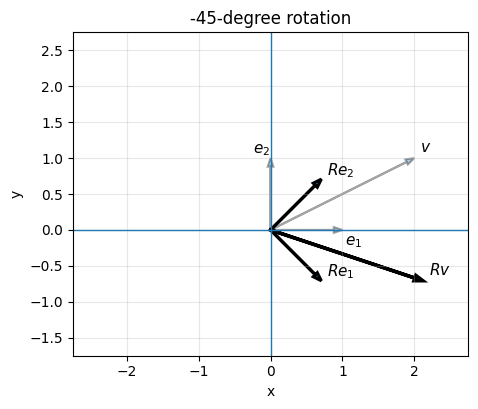

In [4]:
R_minus_45 = rotation_matrix(-45)

show_rotation(R_minus_45, title="-45-degree rotation")

This uses the same formula.

Only the sign of the angle has changed.

## Rotation preserves length

A pure rotation changes direction, but it does not stretch or shrink the vector.

We can check this numerically using the vector norm.

In [5]:
R45 = rotation_matrix(45)
Rv = R45 @ v

print(f"||v||  = {np.linalg.norm(v):.6f}")
print(f"||Rv|| = {np.linalg.norm(Rv):.6f}")

||v||  = 2.236068
||Rv|| = 2.236068


The lengths match.

This is different from scaling, where basis vectors change length.

For rotation:

- $R\mathbf{e}_1$ still has length $1$
- $R\mathbf{e}_2$ still has length $1$
- the transformed basis vectors remain at right angles

So rotation turns the coordinate frame without stretching it.

## The endpoint moves around a circle

If a vector keeps the same length while rotating, its endpoint moves around a circle.

The next plot rotates the same vector through several angles.

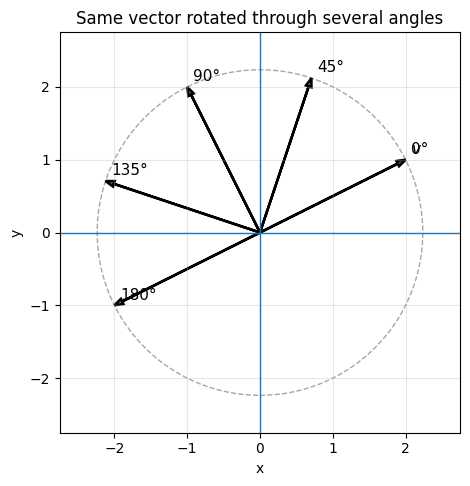

In [6]:
plot_angle_sweep([0, 45, 90, 135, 180])

The endpoint stays the same distance from the origin each time.

Only the direction changes.

## Summary

A 2D rotation matrix is:

$$
R_\theta =
\begin{bmatrix}
\cos(\theta) & -\sin(\theta) \\
\sin(\theta) & \cos(\theta)
\end{bmatrix}
$$

The column view is:

$$
R_\theta\mathbf{e}_1 =
\begin{bmatrix}
\cos(\theta) \\
\sin(\theta)
\end{bmatrix}
\qquad
R_\theta\mathbf{e}_2 =
\begin{bmatrix}
-\sin(\theta) \\
\cos(\theta)
\end{bmatrix}
$$

For a vector:

$$
\mathbf{v} =
\begin{bmatrix}
x \\
y
\end{bmatrix}
=
x\mathbf{e}_1 + y\mathbf{e}_2
$$

rotation gives:

$$
R_\theta\mathbf{v}
=
x(R_\theta\mathbf{e}_1) + y(R_\theta\mathbf{e}_2)
$$

The key points are:

- positive angles rotate counter-clockwise
- negative angles rotate clockwise
- the columns are the rotated basis vectors
- rotation changes direction but preserves length
- the transformed basis vectors stay length $1$ and remain at right angles

So rotation is not a special exception to the matrix story.

It is another case of the same idea:

> move the basis vectors, then rebuild the vector from the moved basis vectors.

## Next step

Next, we can look at combining transformations.